<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/Path_Integral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-164/981778886.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


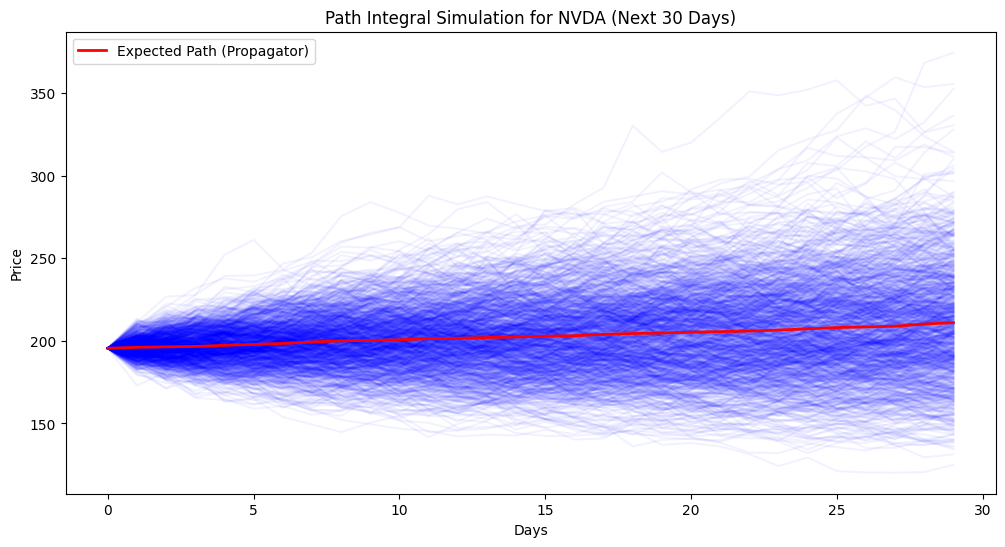

Current Price: 195.56
Expected Price in 30 days: 211.04


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 1. ดึงข้อมูล NVDA เพื่อหาค่า Drift (มิว) และ Volatility (ซิกม่า)
ticker = 'NVDA'
data = yf.download(ticker, start="2024-01-01")['Close']
returns = np.log(data / data.shift(1)).dropna()

# Convert Series to scalar floats
mu = returns.mean().item()
sigma = returns.std().item()
last_price = data.iloc[-1].item()

# 2. ตั้งค่าการจำลอง Path Integral (Monte Carlo Paths)
n_paths = 1000      # จำนวนเส้นทางที่เป็นไปได้ (Path Integral)
n_days = 30         # พยากรณ์ไปข้างหน้า 30 วัน
dt = 1

# สร้าง Array เก็บทุกเส้นทาง
all_paths = np.zeros((n_days, n_paths))
all_paths[0] = last_price

# 3. จำลองการเคลื่อนที่ตามหลัก Quantum Stochastic (Geometric Brownian Motion)
for t in range(1, n_days):
    # สุ่ม "แรงกระตุ้น" ของอนุภาค (Shock)
    z = np.random.standard_normal(n_paths)
    all_paths[t] = all_paths[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

# 4. แสดงผล "กลุ่มหมอกของความเป็นไปได้"
plt.figure(figsize=(12, 6))
plt.plot(all_paths, color='blue', alpha=0.05) # แต่ละเส้นทางคือ 1 Path Integral
plt.plot(np.mean(all_paths, axis=1), color='red', linewidth=2, label='Expected Path (Propagator)')
plt.title(f'Path Integral Simulation for {ticker} (Next 30 Days)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

print(f"Current Price: {last_price:.2f}")
print(f"Expected Price in 30 days: {np.mean(all_paths[-1]):.2f}")

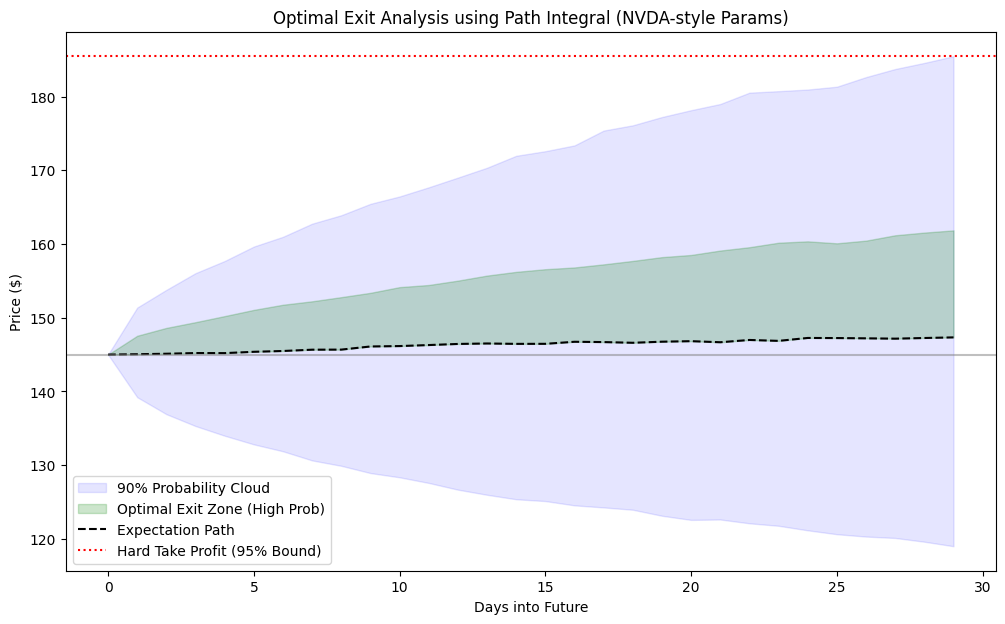

--- Quantum Exit Strategy ---
Optimal Take Profit Target (30D): $161.86 - $185.49
Probability of Price staying above current: 55.14%


In [3]:

# 1. จำลองเส้นทางราคา (Path Integral) 30 วันข้างหน้า
# (ใช้ Logic เดียวกับก่อนหน้า แต่เพิ่มการวิเคราะห์ Distribution)
n_paths = 5000
n_days = 30
last_price = 145.0  # สมมติราคาล่าสุด NVDA
mu = 0.001          # Expected daily return
sigma = 0.025       # Daily Volatility

paths = np.zeros((n_days, n_paths))
paths[0] = last_price
for t in range(1, n_days):
    z = np.random.standard_normal(n_paths)
    paths[t] = paths[t-1] * np.exp((mu - 0.5 * sigma**2) + sigma * z)

# 2. คำนวณขอบเขตความน่าจะเป็น (Quantum Probability Envelopes)
upper_95 = np.percentile(paths, 95, axis=1)
upper_75 = np.percentile(paths, 75, axis=1)
median_path = np.median(paths, axis=1)
lower_05 = np.percentile(paths, 5, axis=1)

# 3. วิเคราะห์ Optimal Exit Point
# เรามองหาจุดที่ "Reward/Risk Ratio" สูงที่สุดในเชิงสถิติ
expected_return = (upper_95[-1] - last_price) / last_price
max_potential_loss = (last_price - lower_05[-1]) / last_price

# 4. แสดงผลโซนการขาย
plt.figure(figsize=(12, 7))
plt.fill_between(range(n_days), lower_05, upper_95, color='blue', alpha=0.1, label='90% Probability Cloud')
plt.fill_between(range(n_days), median_path, upper_75, color='green', alpha=0.2, label='Optimal Exit Zone (High Prob)')

plt.plot(median_path, color='black', linestyle='--', label='Expectation Path')
plt.axhline(y=upper_95[-1], color='red', linestyle=':', label='Hard Take Profit (95% Bound)')
plt.axhline(y=last_price, color='gray', alpha=0.5)

plt.title(f'Optimal Exit Analysis using Path Integral (NVDA-style Params)')
plt.xlabel('Days into Future')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

print(f"--- Quantum Exit Strategy ---")
print(f"Optimal Take Profit Target (30D): ${upper_75[-1]:.2f} - ${upper_95[-1]:.2f}")
print(f"Probability of Price staying above current: {np.mean(paths[-1] > last_price):.2%}")